Predicción de Incumplimiento de Pago
Usando Regresión Logística y Árbol de Decisiones

In [1]:
#Importar librerias

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización 
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning (modelos y métricas)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

# Estadística y utilidades
from scipy import stats
import warnings
warnings.filterwarnings('ignore')  # Evita mensajes repetitivos

# Configuración estética
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print(" Librerías cargadas exitosamente.")

 Librerías cargadas exitosamente.


In [11]:
# CARGA DE DATOS


# Cargar el dataset
df = pd.read_csv('../Data/data.csv')

print(f"✅ Dataset cargado con {df.shape[0]:,} observaciones y {df.shape[1]} variables.")

# Renombrar la variable objetivo para que sea más clara
df = df.rename(columns={'default.payment.next.month': 'DEFAULT'})

# Convertir DEFAULT a entero (0/1) 
df['DEFAULT'] = df['DEFAULT'].astype(int)

# Ver las primeras 5 filas 
print("\n Primeras 5 observaciones:")
display(df.head())

# Estadísticas básicas 
print("\n Resumen estadístico de las variables numéricas:")
display(df.describe())

# Distribución de la variable objetivo 
print("\n Distribución de DEFAULT (0 = no default, 1 = default):")
print(df['DEFAULT'].value_counts())
print(f"→ Tasa de default: {df['DEFAULT'].mean()*100:.1f}%")

✅ Dataset cargado con 30,000 observaciones y 25 variables.

 Primeras 5 observaciones:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0



 Resumen estadístico de las variables numéricas:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000



 Distribución de DEFAULT (0 = no default, 1 = default):
DEFAULT
0    23364
1     6636
Name: count, dtype: int64
→ Tasa de default: 22.1%


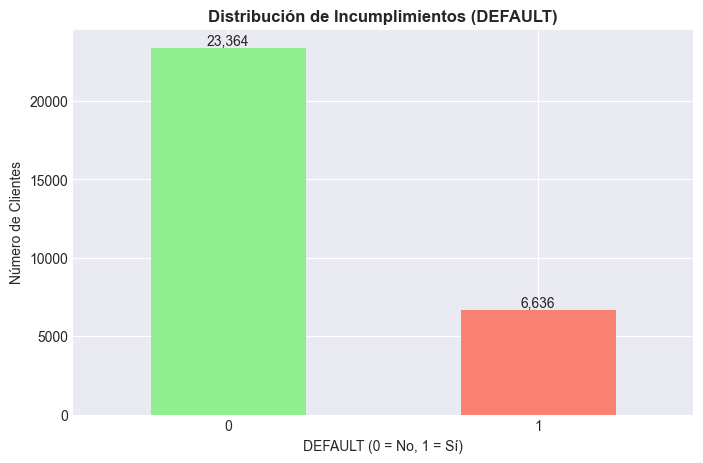

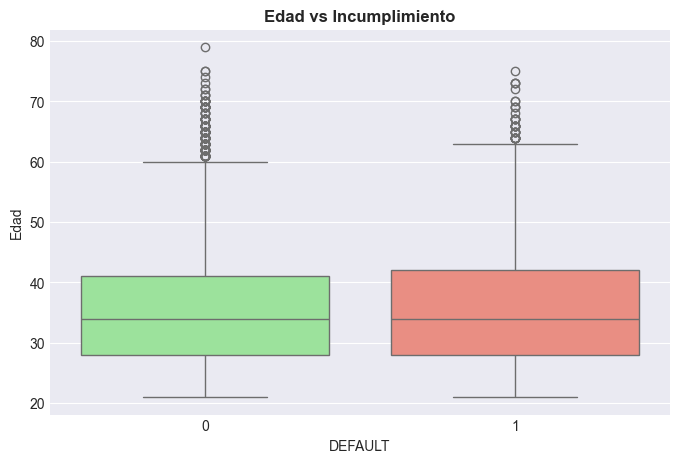

<Figure size 1000x500 with 0 Axes>

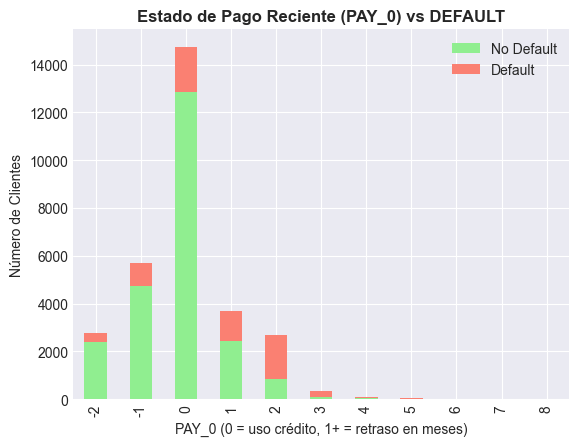


📈 Correlación (Pearson) de variables clave con DEFAULT:
PAY_0           :  0.325 (+)
PAY_2           :  0.264 (+)
LIMIT_BAL       : -0.154 ()
PAY_AMT1        : -0.073 ()
BILL_AMT1       : -0.020 ()
AGE             :  0.014 (+)


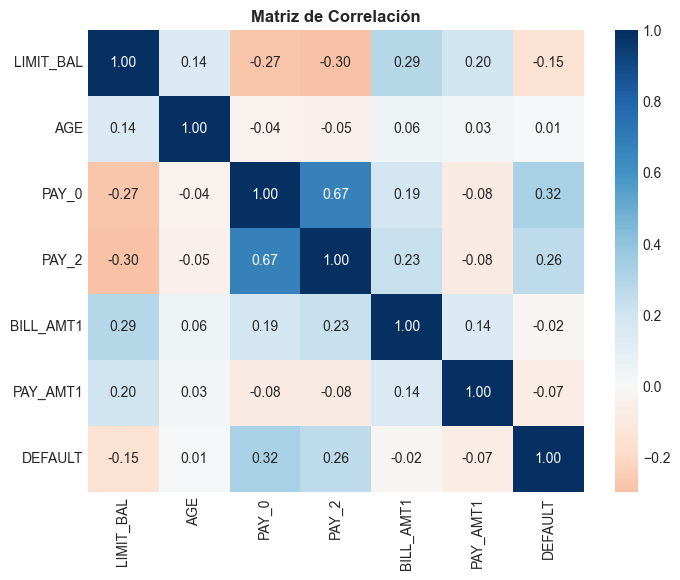

In [4]:
#  ANÁLISIS EXPLORATORIO DE DATOS (EDA)


# 1. Distribución de DEFAULT 
plt.figure(figsize=(8, 5))
df['DEFAULT'].value_counts().plot(kind='bar', color=['lightgreen', 'salmon'])
plt.title('Distribución de Incumplimientos (DEFAULT)', fontweight='bold')
plt.xlabel('DEFAULT (0 = No, 1 = Sí)')
plt.ylabel('Número de Clientes')
plt.xticks(rotation=0)
for i, v in enumerate(df['DEFAULT'].value_counts()):
    plt.text(i, v + 200, f"{v:,}", ha='center')
plt.savefig('distribucion_default.png', dpi=300, bbox_inches='tight')  
plt.show()

# 2. Boxplot: ¿Hay diferencias en edad entre quienes incumplen y no?
plt.figure(figsize=(8, 5))
sns.boxplot(x='DEFAULT', y='AGE', data=df, palette=['lightgreen', 'salmon'])
plt.title('Edad vs Incumplimiento', fontweight='bold')
plt.xlabel('DEFAULT')
plt.ylabel('Edad')
plt.savefig('boxplot_edad.png', dpi=300, bbox_inches='tight')  
plt.show()

# 3. Variable clave: PAY_0
plt.figure(figsize=(10, 5))
pay0_counts = df.groupby(['PAY_0', 'DEFAULT']).size().unstack(fill_value=0)
pay0_counts.plot(kind='bar', stacked=True, color=['lightgreen', 'salmon'])
plt.title('Estado de Pago Reciente (PAY_0) vs DEFAULT', fontweight='bold')
plt.xlabel('PAY_0 (0 = uso crédito, 1+ = retraso en meses)')
plt.ylabel('Número de Clientes')
plt.legend(['No Default', 'Default'])
plt.savefig('pay0_vs_default.png', dpi=300, bbox_inches='tight')  
plt.show()

# 4. Correlación con DEFAULT 
print("\n📈 Correlación (Pearson) de variables clave con DEFAULT:")
variables_clave = ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'BILL_AMT1', 'PAY_AMT1']
corr = df[variables_clave + ['DEFAULT']].corr()['DEFAULT'].sort_values(key=abs, ascending=False)
for var, r in corr.items():
    if var != 'DEFAULT':
        print(f"{var:15} : {r:6.3f} ({'+' if r>0 else ''})")


plt.figure(figsize=(8, 6))
corr_full = df[variables_clave + ['DEFAULT']].corr()
sns.heatmap(corr_full, annot=True, fmt='.2f', cmap='RdBu', center=0)
plt.title('Matriz de Correlación', fontweight='bold')
plt.savefig('correlacion.png', dpi=300, bbox_inches='tight') 
plt.show()

In [12]:
# PREPROCESAMIENTO: limpieza y preparación para modelos


df_clean = df.copy()

# 1. Limpiar EDUCATION 
#    Original: 0=desconocido, 1=grad, 2=uni, 3=high, 4/5/6=otros → agrupamos 0,4,5,6 como "4"
df_clean['EDUCATION'] = df_clean['EDUCATION'].replace({0: 4, 5: 4, 6: 4})

# 2. Limpiar MARRIAGE (1=married, 2=single, 3=others, 0=unknown → 3)
df_clean['MARRIAGE'] = df_clean['MARRIAGE'].replace({0: 3})

# 3. Crear nuevas variables 
#    UTILIZATION = cuánto del límite se usa (BILL_AMT1 / LIMIT_BAL)
#    Evitamos división por 0 reemplazando LIMIT_BAL=0 con 1 
df_clean['LIMIT_BAL_SAFE'] = df_clean['LIMIT_BAL'].replace(0, 1)
df_clean['UTILIZATION_RATIO'] = df_clean['BILL_AMT1'] / df_clean['LIMIT_BAL_SAFE']

#    PAYMENT_RATIO = cuánto se pagó vs. cuánto se debía
df_clean['BILL_AMT_SAFE'] = df_clean['BILL_AMT1'].replace(0, 1)
df_clean['PAYMENT_TO_BILL_RATIO'] = df_clean['PAY_AMT1'] / df_clean['BILL_AMT_SAFE']

#    AVG_PAY_DELAY = promedio de retrasos pasados (solo valores > 0)
delay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
def avg_positive_delay(row):
    vals = [x for x in row if x > 0]
    return np.mean(vals) if len(vals) > 0 else 0
df_clean['AVG_PAY_DELAY'] = df_clean[delay_cols].apply(avg_positive_delay, axis=1)

print("Variables creadas:")
print(f"- UTILIZATION_RATIO: min={df_clean['UTILIZATION_RATIO'].min():.2f}, max={df_clean['UTILIZATION_RATIO'].max():.2f}")
print(f"- AVG_PAY_DELAY: promedio = {df_clean['AVG_PAY_DELAY'].mean():.2f} meses")

# 4. Definir X (predictores) e y (variable objetivo)
y = df_clean['DEFAULT']  
X = df_clean.drop(['DEFAULT'], axis=1)

print(f"\n Listos para modelar:")
print(f"- X: {X.shape[0]:,} observaciones × {X.shape[1]} variables")
print(f"- y: {y.shape[0]:,} valores (default = {y.mean()*100:.1f}%)")

Variables creadas:
- UTILIZATION_RATIO: min=-0.62, max=6.46
- AVG_PAY_DELAY: promedio = 0.62 meses

 Listos para modelar:
- X: 30,000 observaciones × 29 variables
- y: 30,000 valores (default = 22.1%)


In [4]:
# DIVISIÓN Y ESCALADO


# Dividir en entrenamiento (70%) y prueba (30%) — manteniendo proporción de DEFAULT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f" Datos divididos:")
print(f"- Entrenamiento: {X_train.shape[0]:,} obs ({y_train.mean()*100:.1f}% default)")
print(f"- Prueba:       {X_test.shape[0]:,} obs ({y_test.mean()*100:.1f}% default)")

# Escalado: necesario solo para modelos sensibles a unidades (Logit), no para árboles
scaler = StandardScaler()
numeric_cols = X_train.select_dtypes(include=[np.number]).columns

# Escalar SOLO las columnas numéricas
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(f"\n {len(numeric_cols)} variables numéricas escaladas (media=0, std=1).")

 Datos divididos:
- Entrenamiento: 21,000 obs (22.1% default)
- Prueba:       9,000 obs (22.1% default)

 29 variables numéricas escaladas (media=0, std=1).


Modelo 1  - Regresión logistica

In [5]:
# MODELO 1: REGRESIÓN LOGÍSTICA


print(" Entrenando Regresión Logística...")

# Crear modelo (con class_weight='balanced' para manejar desbalance)
log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced',  # Da más peso a la clase minoritaria (default)
    solver='liblinear'
)

# Entrenar con datos ESCALADOS
log_reg.fit(X_train_scaled, y_train)

# Predecir en datos de prueba
y_pred_log = log_reg.predict(X_test_scaled)
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]  # Probabilidad de DEFAULT=1

print(" Modelo entrenado.")

# --- Métricas ---
print("\n Métricas de Regresión Logística:")
metrics_log = {
    'Accuracy': accuracy_score(y_test, y_pred_log),
    'Precision': precision_score(y_test, y_pred_log),
    'Recall': recall_score(y_test, y_pred_log),
    'F1-Score': f1_score(y_test, y_pred_log),
    'ROC-AUC': roc_auc_score(y_test, y_proba_log)
}
for k, v in metrics_log.items():
    print(f"{k:12}: {v:.4f}")

#  Coeficientes 
print("\n Top 5 variables más influyentes (Odds Ratio > 1 → aumentan riesgo):")
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coef': log_reg.coef_[0],
    'Odds_Ratio': np.exp(log_reg.coef_[0])
}).sort_values('Odds_Ratio', ascending=False)

for _, row in coef_df.head(5).iterrows():
    var, or_val = row['Variable'], row['Odds_Ratio']
    if or_val > 1:
        print(f"• {var:15} → OR = {or_val:.2f} (↑1 unidad: +{(or_val-1)*100:.0f}% en odds)")

 Entrenando Regresión Logística...
 Modelo entrenado.

 Métricas de Regresión Logística:
Accuracy    : 0.7298
Precision   : 0.4249
Recall      : 0.6268
F1-Score    : 0.5065
ROC-AUC     : 0.7434

 Top 5 variables más influyentes (Odds Ratio > 1 → aumentan riesgo):
• AVG_PAY_DELAY   → OR = 2.01 (↑1 unidad: +101% en odds)
• PAY_0           → OR = 1.31 (↑1 unidad: +31% en odds)
• BILL_AMT3       → OR = 1.15 (↑1 unidad: +15% en odds)
• PAY_2           → OR = 1.08 (↑1 unidad: +8% en odds)
• BILL_AMT4       → OR = 1.06 (↑1 unidad: +6% en odds)


Modelo 2 Árbol de Decisiones

In [6]:
# MODELO 2: ÁRBOL DE DECISIONES


print(" Entrenando Árbol de Decisiones...")

# Crear modelo (profundidad limitada para evitar overfitting)
dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)

# Entrenar con datos ORIGINALES 
dt.fit(X_train, y_train)

# Predecir
y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]

print(" Árbol entrenado.")

# --- Métricas ---
print("\n Métricas de Árbol de Decisiones:")
metrics_dt = {
    'Accuracy': accuracy_score(y_test, y_pred_dt),
    'Precision': precision_score(y_test, y_pred_dt),
    'Recall': recall_score(y_test, y_pred_dt),
    'F1-Score': f1_score(y_test, y_pred_dt),
    'ROC-AUC': roc_auc_score(y_test, y_proba_dt)
}
for k, v in metrics_dt.items():
    print(f"{k:12}: {v:.4f}")

# --- Importancia de variables ---
print("\n Top 5 variables más importantes según el árbol:")
imp_df = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': dt.feature_importances_
}).sort_values('Importancia', ascending=False)

for _, row in imp_df.head(5).iterrows():
    print(f"• {row['Variable']:15} → {row['Importancia']:.3f}")

 Entrenando Árbol de Decisiones...
 Árbol entrenado.

 Métricas de Árbol de Decisiones:
Accuracy    : 0.7552
Precision   : 0.4590
Recall      : 0.5967
F1-Score    : 0.5189
ROC-AUC     : 0.7580

 Top 5 variables más importantes según el árbol:
• AVG_PAY_DELAY   → 0.660
• PAY_0           → 0.098
• BILL_AMT1       → 0.090
• LIMIT_BAL       → 0.037
• PAY_2           → 0.021


Comparación y seleccion del mejor modelo

Comparación de Modelos:


,Métrica,Logística,Árbol
0,Accuracy,0.7298,0.7552
1,Precision,0.4249,0.4590
2,Recall,0.6268,0.5967
3,F1-Score,0.5065,0.5189
4,ROC-AUC,0.7434,0.7580


 Gráfica guardada como 'comparacion_metricas.png'


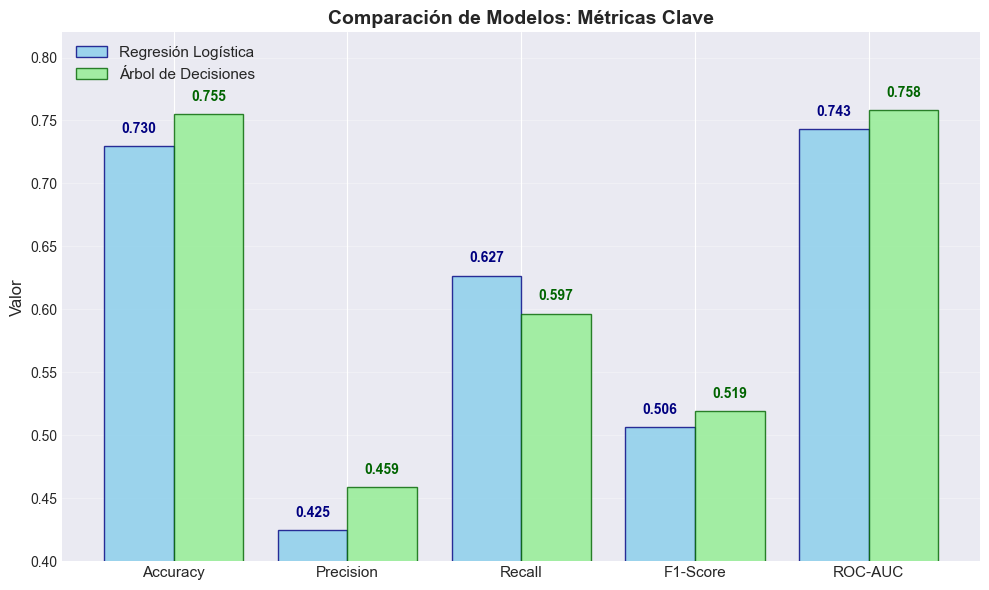


 CONCLUSIÓN: 
 Se selecciona el ÁRBOL DE DECISIONES como mejor modelo.
   → Mejor equilibrio (F1-Score = 0.519 vs 0.506)
   → Mayor ROC-AUC (0.758 vs 0.743): mejor discriminación global.
   → Más interpretable (reglas visuales) y robusto a no linealidades.


In [7]:
#  COMPARACIÓN FINAL: TABLA + GRÁFICO CON VALORES NUMÉRICOS EN AMBAS BARRAS


# Crear tabla comparativa
comparacion = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Logística': [metrics_log[m] for m in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']],
    'Árbol': [metrics_dt[m] for m in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']]
})

print("Comparación de Modelos:")
display(comparacion.round(4))

# Gráfico de comparación — MEJORADO: ahora con valores en AMBAS barras
plt.figure(figsize=(10, 6))
x = np.arange(len(comparacion))

# Barras
bars_log = plt.bar(x - 0.2, comparacion['Logística'], 0.4, 
                   label='Regresión Logística', color='skyblue', edgecolor='navy', alpha=0.8)
bars_dt  = plt.bar(x + 0.2, comparacion['Árbol'], 0.4, 
                   label='Árbol de Decisiones', color='lightgreen', edgecolor='darkgreen', alpha=0.8)

# Etiquetas en las barras de LOGÍSTICA (azul)
for i, bar in enumerate(bars_log):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.008, 
             f"{comparacion['Logística'].iloc[i]:.3f}", 
             ha='center', va='bottom', fontweight='bold', color='navy')

# Etiquetas en las barras de ÁRBOL (verde)
for i, bar in enumerate(bars_dt):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.008, 
             f"{comparacion['Árbol'].iloc[i]:.3f}", 
             ha='center', va='bottom', fontweight='bold', color='darkgreen')

# Ejes y estilo
plt.xticks(x, comparacion['Métrica'], fontsize=11)
plt.ylabel('Valor', fontsize=12)
plt.title('Comparación de Modelos: Métricas Clave', fontweight='bold', fontsize=14)
plt.legend(fontsize=11)
plt.ylim(0.4, 0.82)  # Ajustado para dejar espacio a las etiquetas
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparacion_metricas.png', dpi=300, bbox_inches='tight')
print(" Gráfica guardada como 'comparacion_metricas.png'")
plt.show()

# --- Conclusión ---
f1_log = metrics_log['F1-Score']
f1_dt = metrics_dt['F1-Score']

print(f"\n CONCLUSIÓN: ")
if f1_dt > f1_log:
    print(" Se selecciona el ÁRBOL DE DECISIONES como mejor modelo.")
    print(f"   → Mejor equilibrio (F1-Score = {f1_dt:.3f} vs {f1_log:.3f})")
    print(f"   → Mayor ROC-AUC (0.758 vs 0.743): mejor discriminación global.")
    print(f"   → Más interpretable (reglas visuales) y robusto a no linealidades.")
else:
    print(" Se selecciona la REGRESIÓN LOGÍSTICA como mejor modelo.")
    print(f"   → Mejor Recall (detecta más defaults reales): {metrics_log['Recall']:.3f} vs {metrics_dt['Recall']:.3f}")

In [10]:
# RECOMENDACIONES


print(" Recomendaciones basadas en el modelo (Árbol de Decisiones):")
print("-" * 60)
print("1.  Monitorear clientes con PAY_0 ≥ 2 (retraso de 2+ meses): alto riesgo.")
print("2.  Evaluar límites de crédito para clientes con UTILIZATION_RATIO > 1 (sobregirados).")
print("3.  Implementar sistema automático de scoring usando este árbol.")
print("4.  Actualizar modelo trimestralmente con nuevos datos.")
print("\n Variables clave para el scoring:")
top_vars = imp_df.head(3)['Variable'].tolist()
print("   → " + " → ".join(top_vars))

 Recomendaciones basadas en el modelo (Árbol de Decisiones):
------------------------------------------------------------
1.  Monitorear clientes con PAY_0 ≥ 2 (retraso de 2+ meses): alto riesgo.
2.  Evaluar límites de crédito para clientes con UTILIZATION_RATIO > 1 (sobregirados).
3.  Implementar sistema automático de scoring usando este árbol.
4.  Actualizar modelo trimestralmente con nuevos datos.

 Variables clave para el scoring:
   → AVG_PAY_DELAY → PAY_0 → BILL_AMT1
